In [17]:
import time

from data_generation import generate_contrasts, generate_design, generate_response
from SI.Practical_TM_SI import practical_TM_SI_randj
import matplotlib.pyplot as plt
import numpy as np

In [18]:
p, nt, ns, K = 100, 30, 50, 2
V = 3
sigma = 1.0
S = 5 # target support: the first S coordinates
H = 2.0 # source contrast c_j ~ N(0, (H/50)^2) on the first 50 coordinates

deltas = [0.25, 0.5, 1.0, 2.0]   # signal strength on the target support
n_rep = 500
alpha = 0.05
n_jobs = 12

In [20]:
rng = np.random.default_rng(2026)

X0, X_list = generate_design(rng, p, nt, ns, K)
contrasts = generate_contrasts(rng, p, K, H)

support = np.arange(S)
Sigma_0 = sigma ** 2 * np.eye(nt)
Sigma_K = [sigma ** 2 * np.eye(ns) for _ in range(K)]

In [13]:
kkt = {"observed fits": 0, "observed violations": 0, "SI fits": 0, "SI violations": 0}
invalid = []   # (delta, iteration, p-value) of non-finite or out-of-range p-values, left out


def run(delta, n_rep):
    beta0 = np.zeros(p)
    beta0[support] = delta
    p_values, branches, n_missed = [], {}, 0
    start = time.perf_counter()

    for i in range(1, n_rep + 1):
        y0, y_list = generate_response(rng, X0, X_list, sigma, beta0, contrasts)

        result = practical_TM_SI_randj(
            X0, y0, X_list, y_list, Sigma_0, Sigma_K,
            V=V, rng=rng, candidates=support, n_jobs=n_jobs,
        )

        kkt["observed fits"] += result['kkt_observed']['fits']
        kkt["observed violations"] += result['kkt_observed']['violations']
        if result['results']:
            p_value = result['results'][0]['p_value']
            if np.isfinite(p_value) and 0.0 <= p_value <= 1.0:
                p_values.append(p_value)
                branches[result['branch']] = branches.get(result['branch'], 0) + 1
            else:
                invalid.append((delta, i, p_value))
            kkt["SI fits"] += result['results'][0]['kkt_si']['fits']
            kkt["SI violations"] += result['results'][0]['kkt_si']['violations']
        else:
            n_missed += 1

        if i % 50 == 0:
            print(f"delta={delta}, {i}/{n_rep}, "
                  f"tests: {len(p_values)}, "
                  f"no true feature selected: {n_missed}, "
                  f"invalid p-values: {len(invalid)}, "
                  f"time: {time.perf_counter() - start:.0f}s, "
                  f"KKT violations: observed {kkt['observed violations']}/{kkt['observed fits']}, "
                  f"SI {kkt['SI violations']}/{kkt['SI fits']}")

    return np.array(p_values), branches, n_missed

In [14]:
# Power for one true feature drawn uniformly from the selected true features.
# Repetitions without a selected true feature are counted separately,
# and excluded from this conditional power estimate.
tpr, n_tests = {}, {}
for delta in deltas:
    p_values, branches, n_missed = run(delta, n_rep)
    tpr[delta] = float(np.mean(p_values <= alpha)) if p_values.size else np.nan
    n_tests[delta] = p_values.size
    print(f"delta={delta}: tests {p_values.size}, no true feature selected {n_missed}, "
          f"branches {branches}, TPR (selected true features) = {tpr[delta]:.3f}")

delta=0.25, 50/500, tests: 34, no true feature selected: 16, invalid p-values: 0, time: 81s, KKT violations: observed 0/16000, SI 7/278599
delta=0.25, 100/500, tests: 76, no true feature selected: 24, invalid p-values: 0, time: 169s, KKT violations: observed 0/32000, SI 11/620519


c:\Ananconda\Lib\site-packages\skglm\utils\anderson.py:43: RuntimeWarning: divide by zero encountered in divide
  C = inv_UTU_ones / np.sum(inv_UTU_ones)
c:\Ananconda\Lib\site-packages\skglm\utils\anderson.py:45: RuntimeWarning: invalid value encountered in matmul
  return self.arr_w_[:, 1:] @ C, self.arr_Xw_[:, 1:] @ C, True


delta=0.25, 150/500, tests: 119, no true feature selected: 31, invalid p-values: 0, time: 263s, KKT violations: observed 1/48000, SI 21/977367
delta=0.25, 200/500, tests: 165, no true feature selected: 35, invalid p-values: 0, time: 375s, KKT violations: observed 1/64000, SI 31/1362072
delta=0.25, 250/500, tests: 208, no true feature selected: 42, invalid p-values: 0, time: 471s, KKT violations: observed 1/80000, SI 37/1696798


c:\Ananconda\Lib\site-packages\skglm\utils\anderson.py:43: RuntimeWarning: divide by zero encountered in divide
  C = inv_UTU_ones / np.sum(inv_UTU_ones)
c:\Ananconda\Lib\site-packages\skglm\utils\anderson.py:45: RuntimeWarning: invalid value encountered in matmul
  return self.arr_w_[:, 1:] @ C, self.arr_Xw_[:, 1:] @ C, True


delta=0.25, 300/500, tests: 248, no true feature selected: 52, invalid p-values: 0, time: 559s, KKT violations: observed 1/96000, SI 49/2013582
delta=0.25, 350/500, tests: 292, no true feature selected: 58, invalid p-values: 0, time: 657s, KKT violations: observed 1/112000, SI 56/2369421
delta=0.25, 400/500, tests: 329, no true feature selected: 71, invalid p-values: 0, time: 746s, KKT violations: observed 1/128000, SI 66/2680661
delta=0.25, 450/500, tests: 368, no true feature selected: 82, invalid p-values: 0, time: 829s, KKT violations: observed 1/144000, SI 69/2999349
delta=0.25, 500/500, tests: 406, no true feature selected: 94, invalid p-values: 0, time: 912s, KKT violations: observed 1/160000, SI 74/3306204
delta=0.25: tests 406, no true feature selected 94, branches {'transmission': 406}, TPR (selected true features) = 0.091
delta=0.5, 50/500, tests: 50, no true feature selected: 0, invalid p-values: 0, time: 150s, KKT violations: observed 2/176000, SI 83/3754821
delta=0.5, 100

...

delta=1.0, 450/500, tests: 450, no true feature selected: 0, invalid p-values: 0, time: 1469s, KKT violations: observed 3/464000, SI 279/12074880
delta=1.0, 500/500, tests: 500, no true feature selected: 0, invalid p-values: 0, time: 1636s, KKT violations: observed 4/480000, SI 288/12565220
delta=1.0: tests 500, no true feature selected 0, branches {'transmission': 500}, TPR (selected true features) = 0.500
delta=2.0, 50/500, tests: 50, no true feature selected: 0, invalid p-values: 0, time: 198s, KKT violations: observed 5/496000, SI 298/13056744


c:\Ananconda\Lib\site-packages\skglm\utils\anderson.py:43: RuntimeWarning: divide by zero encountered in divide
  C = inv_UTU_ones / np.sum(inv_UTU_ones)
c:\Ananconda\Lib\site-packages\skglm\utils\anderson.py:45: RuntimeWarning: invalid value encountered in matmul
  return self.arr_w_[:, 1:] @ C, self.arr_Xw_[:, 1:] @ C, True


delta=2.0, 100/500, tests: 100, no true feature selected: 0, invalid p-values: 0, time: 2003s, KKT violations: observed 5/512000, SI 419/13547380
delta=2.0, 150/500, tests: 150, no true feature selected: 0, invalid p-values: 0, time: 2189s, KKT violations: observed 6/528000, SI 428/14036277


c:\Ananconda\Lib\site-packages\skglm\utils\anderson.py:43: RuntimeWarning: divide by zero encountered in divide
  C = inv_UTU_ones / np.sum(inv_UTU_ones)
c:\Ananconda\Lib\site-packages\skglm\utils\anderson.py:45: RuntimeWarning: invalid value encountered in matmul
  return self.arr_w_[:, 1:] @ C, self.arr_Xw_[:, 1:] @ C, True


delta=2.0, 200/500, tests: 200, no true feature selected: 0, invalid p-values: 0, time: 2363s, KKT violations: observed 6/544000, SI 430/14528646
delta=2.0, 250/500, tests: 250, no true feature selected: 0, invalid p-values: 0, time: 2534s, KKT violations: observed 7/560000, SI 432/15023428
delta=2.0, 300/500, tests: 300, no true feature selected: 0, invalid p-values: 0, time: 2707s, KKT violations: observed 8/576000, SI 433/15519127
delta=2.0, 350/500, tests: 350, no true feature selected: 0, invalid p-values: 0, time: 2882s, KKT violations: observed 8/592000, SI 436/16013028
delta=2.0, 400/500, tests: 400, no true feature selected: 0, invalid p-values: 0, time: 3052s, KKT violations: observed 8/608000, SI 438/16498363
delta=2.0, 450/500, tests: 450, no true feature selected: 0, invalid p-values: 0, time: 3221s, KKT violations: observed 10/624000, SI 446/16986623
delta=2.0, 500/500, tests: 500, no true feature selected: 0, invalid p-values: 0, time: 3410s, KKT violations: observed 10/

In [15]:
print(f"TPR (selected true features): {tpr}")
print(f"tests: {n_tests}")
print(f"invalid p-values: {len(invalid)}")
print(f"KKT violations: observed {kkt['observed violations']} / {kkt['observed fits']} fits, "
      f"SI {kkt['SI violations']} / {kkt['SI fits']} fits")

TPR (selected true features): {0.25: 0.09113300492610837, 0.5: 0.22444889779559118, 1.0: 0.5, 2.0: 0.662}
tests: {0.25: 406, 0.5: 499, 1.0: 500, 2.0: 500}
invalid p-values: 0
KKT violations: observed 10 / 640000 fits, SI 451 / 17472932 fits


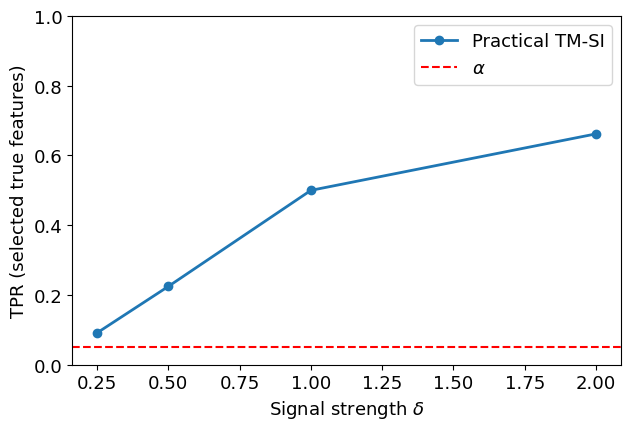

In [16]:
plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(6.5, 4.5))
plt.plot(deltas, [tpr[d] for d in deltas], marker='o', linewidth=2, label='Practical TM-SI')
plt.axhline(alpha, color='red', linestyle='--', linewidth=1.5, label=r'$\alpha$')
plt.ylim(0, 1)
plt.xlabel(r'Signal strength $\delta$')
plt.ylabel('TPR (selected true features)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Power versus target sample size: larger p, more sources, larger sources.
p_nt, K_nt, ns_nt = 300, 4, 100
delta_nt = 0.5
nts = [30, 50, 100, 150, 200]   # target sample sizes
n_rep_nt = 150
n_jobs = 16

rng_nt = np.random.default_rng(2026)

In [ ]:
kkt_nt = {"observed fits": 0, "observed violations": 0, "SI fits": 0, "SI violations": 0}
invalid_nt = []   # (n_T, iteration, p-value) of non-finite or out-of-range p-values, left out


def run_nt(nt_size, n_rep):
    X0, X_list = generate_design(rng_nt, p_nt, nt_size, ns_nt, K_nt)
    contrasts = generate_contrasts(rng_nt, p_nt, K_nt, H)
    beta0 = np.zeros(p_nt)
    beta0[support] = delta_nt
    Sigma_0 = sigma ** 2 * np.eye(nt_size)
    Sigma_K = [sigma ** 2 * np.eye(ns_nt) for _ in range(K_nt)]
    p_values, sizes, n_missed = [], [], 0
    start = time.perf_counter()

    for i in range(1, n_rep + 1):
        y0, y_list = generate_response(rng_nt, X0, X_list, sigma, beta0, contrasts)

        result = practical_TM_SI_randj(
            X0, y0, X_list, y_list, Sigma_0, Sigma_K,
            V=V, rng=rng_nt, candidates=support, n_jobs=n_jobs,
        )

        sizes.append(len(result['selected_model']))
        kkt_nt["observed fits"] += result['kkt_observed']['fits']
        kkt_nt["observed violations"] += result['kkt_observed']['violations']
        if result['results']:
            p_value = result['results'][0]['p_value']
            if np.isfinite(p_value) and 0.0 <= p_value <= 1.0:
                p_values.append(p_value)
            else:
                invalid_nt.append((nt_size, i, p_value))
            kkt_nt["SI fits"] += result['results'][0]['kkt_si']['fits']
            kkt_nt["SI violations"] += result['results'][0]['kkt_si']['violations']
        else:
            n_missed += 1

        if i % 25 == 0:
            print(f"n_T={nt_size}, {i}/{n_rep}, "
                  f"tests: {len(p_values)}, "
                  f"no true feature selected: {n_missed}, "
                  f"invalid p-values: {len(invalid_nt)}, "
                  f"time: {time.perf_counter() - start:.0f}s, "
                  f"KKT violations: observed {kkt_nt['observed violations']}/{kkt_nt['observed fits']}, "
                  f"SI {kkt_nt['SI violations']}/{kkt_nt['SI fits']}")

    return np.array(p_values), np.mean(sizes), n_missed

In [ ]:
tpr_nt, se_nt, n_tests_nt, size_nt = {}, {}, {}, {}
for nt_size in nts:
    p_values, size_nt[nt_size], n_missed = run_nt(nt_size, n_rep_nt)
    tpr_nt[nt_size] = float(np.mean(p_values <= alpha)) if p_values.size else np.nan
    se_nt[nt_size] = float(np.sqrt(tpr_nt[nt_size] * (1 - tpr_nt[nt_size]) / p_values.size)) if p_values.size else np.nan
    n_tests_nt[nt_size] = p_values.size
    print(f"n_T={nt_size}: tests {p_values.size}, no true feature selected {n_missed}, "
          f"mean |M| {size_nt[nt_size]:.1f}, TPR (selected true features) = {tpr_nt[nt_size]:.3f}")

In [ ]:
print(f"{'n_T':>5} {'tests':>6} {'TPR':>7} {'s.e.':>7} {'mean |M|':>9}")
for nt_size in nts:
    print(f"{nt_size:>5} {n_tests_nt[nt_size]:>6} {tpr_nt[nt_size]:>7.3f} {se_nt[nt_size]:>7.3f} {size_nt[nt_size]:>9.1f}")
print(f"invalid p-values: {len(invalid_nt)}")
print(f"KKT violations: observed {kkt_nt['observed violations']} / {kkt_nt['observed fits']} fits, "
      f"SI {kkt_nt['SI violations']} / {kkt_nt['SI fits']} fits")

In [ ]:
plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(6.5, 4.5))
plt.errorbar(nts, [tpr_nt[n] for n in nts], yerr=[se_nt[n] for n in nts],
             marker='o', linewidth=2, capsize=4, label='Practical TM-SI')
plt.axhline(alpha, color='red', linestyle='--', linewidth=1.5, label=r'$\alpha$')
plt.ylim(0, 1)
plt.xlabel(r'Target sample size $n_T$')
plt.ylabel('TPR (selected true features)')
plt.legend()
plt.tight_layout()
plt.show()